In [1]:
import numpy as np
import pandas as pd

from numba import jit, prange, njit
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from pyscarcopula.src.Frank.FrankCopula  import FrankCopula
from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula

from pyscarcopula.aux_functions.funcs import jit_pobs, pobs
import math
from scipy.optimize import minimize, Bounds

In [2]:
moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']

moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = pobs(moex_returns)


count_instruments = len(tickers)
copula = GumbelCopula(count_instruments)

In [3]:
T = len(pobs_data)
latent_process_tr = 1000
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

In [4]:
t_data = np.linspace(0, 1, num = T)
alpha = np.array([2.0, -2.0, 0.1])
alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]

In [5]:
@jit(nopython=True, parallel = True, cache = True)
def p_sampler_ou(alpha, dwt, init_state = None):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    mu = -alpha1 / alpha2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for k in range(1, T):
        xt[k] = xt[k - 1] + (alpha1 + alpha2 * xt[k - 1]) * dt + alpha3 * dwt[k]
    return xt

@jit(nopython = True, cache = True, parallel = True)
def get_avg_p_log_likelihood_ou(data, lambda_data, latent_process_tr, pdf, transform):
    avg_likelihood = 0
    copula_log_data = np.zeros(latent_process_tr)

    for k in prange(0, latent_process_tr):
        copula_log_data[k] = np.sum(np.log(np.maximum(pdf(data, transform(lambda_data[:,k])), 1e-100)))

    '''trick for calculation large values. calculate e^(sum(log_cop) - corr) instead of e^(sum(log_cop)).
    Do inverse correction at the end of calculations'''
    corr = max(copula_log_data)
    avg_likelihood = np.sum(np.exp(copula_log_data - corr)) / latent_process_tr
    return math.log(avg_likelihood) + corr


@jit(nopython = True, cache = True)
def p_jit_mlog_likelihood_ou(alpha: np.array, data: np.array, dwt: np.array, latent_process_tr: int,
                      print_path: bool, pdf: callable, transform: callable, init_state: np.array = None) -> float:
    
    '''initial data check'''
    if np.isnan(np.sum(alpha)) == True:
        res = 10000
        if print_path == True:
            print(alpha, 'incorrect params', res)
        return res
    
    lambda_data = p_sampler_ou(alpha, dwt, init_state)
    avg_log_likelihood = get_avg_p_log_likelihood_ou(data.T, lambda_data, latent_process_tr, pdf, transform)
    res = - avg_log_likelihood
    if np.isnan(res) == True:
        if print_path == True:
            print(alpha, 'unknown error', res)
    else:
        if print_path == True:
            print(alpha, res)
    return res


In [16]:
@jit(nopython=True, cache = True)
def moving_average(a, n = 3):
    ret = np.cumsum(a)
    ret[n:] = ret[n:] - ret[:-n]
    ret = ret[n - 1:] / n
    lin_arr1 = np.linspace(a[0], ret[0], n//2)
    index = len(a) - (len(lin_arr1) + len(ret))
    lin_arr2 = np.linspace(ret[-1], a[-1], index)
    ret = np.concatenate((lin_arr1, ret, lin_arr2 ))
    return ret

@jit(nopython=True, cache = True)
def linear_least_squares(matA: np.array, matB: np.array, alpha = 0.0) -> np.array:
    '''Ridge regression
       Input  Ax = b
       Output x = (A.T * A + alpha * I) ^ (-1) * A.T * b
    '''
    I = np.identity(len(matA[0]))
    I[0][0] = 0
    return np.linalg.inv( matA.T @ matA + alpha * I) @ matA.T @ matB 

@jit(nopython=True, cache = True)
def poly_fit(x, y, dim, fit_intercept = True, ridge_alpha = 0.0):
    '''least squares fit y = f(x), where f(x) - polynom with dimension = dim'''
    fi = int(fit_intercept)
    A = np.zeros((len(x), dim + fi))
    x_i = x
    for i in range(0, dim):
        #A[:,i + fi] = x**(i + 1)
        A[:,i + fi] = x_i
        x_i = x_i  * x
    if fit_intercept == True:
        A[:,0] = np.ones(len(x))
    res = linear_least_squares(A, y, ridge_alpha)
    return res

@jit(nopython=True, cache = True)
def poly(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, dim):
        res += coef[i] * data**(1 - fi + i)
    return res

@jit(nopython=True, cache = True)
def poly_corr_old(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 1
    exp_res = np.exp(-0.05*(max_res - res))
    return 1 / (1 + exp_res) * res

# @jit(nopython=True, cache = True)
# def bounded_polynom_fit(x, y, deg, ridge_alpha = 0.0):
#     c1 = x[0]
#     c2 = x[-1]
#     d1 = -c1 - c2
#     d2 = c1 * c2

#     A = np.zeros((len(x), deg - 2))
#     x_i = np.ones(len(x))
#     for i in range(0, deg - 2):
#         A[:,i] = x_i * x * x + d1 * x_i * x + d2 * x
#         x_i = x_i  * x
#     res = linear_least_squares(A, y, ridge_alpha)
#     return res

# @jit(nopython=True, cache = True)
# def bounded_polynom(data, coef):
#     deg = len(coef)
#     c1 = data[0]
#     c2 = data[-1]
#     d1 = -c1 - c2
#     d2 = c1 * c2
    
#     res = np.zeros(len(data))
#     data_i = np.ones(len(data))
#     for i in range(0, deg):
#         res += coef[i] * data_i
#         data_i = data_i * data
#     return (data * data + d1 * data + d2) * res


@jit(nopython=True, cache = True)
def bounded_polynom_fit(x, y, deg, ridge_alpha = 0.0):
    x0 = x[0]
    x1 = x[-1]
    y0 = y[0]
    y1 = y[-1]
    c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
    c1 = (y1 - y0) / (x1 - x0)
    d1 = -x0 - x1
    d2 = x0 * x1

    A = np.zeros((len(x), deg - 2))
    x_i = np.ones(len(x))
    for i in range(0, deg - 2):
        A[:,i] = x_i * x * x + d1 * x_i * x + d2 * x
        x_i = x_i  * x
    A[:,0] += np.ones(len(x)) * c0
    A[:,1] += x * c1
    res = linear_least_squares(A, y, ridge_alpha)
    return res

@jit(nopython=True, cache = True)
def bounded_polynom(x, y, coef):
    deg = len(coef)
    x0 = x[0]
    x1 = x[-1]
    y0 = y[0]
    y1 = y[-1]
    c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
    c1 = (y1 - y0) / (x1 - x0)
    d1 = -x0 - x1
    d2 = x0 * x1
    
    res = np.zeros(len(x))
    x_i = np.ones(len(x))
    for i in range(0, deg):
        res += coef[i] * x_i
        x_i = x_i * x
    return (x * x + d1 * x + d2) * res + c1 * x + c0


@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 50
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def poly_corr(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    #max_res = 1 / (2 * sigma2[-1]) - 0.5
    #max_res = 1 / (2 * sigma2[-1]) - 0.0
    max_res = 0.0
    # exp_res = np.exp(-1*(max_res - res))
    # return 1 / (1 + exp_res) * res
    return -(mod_abs(max_res - res) - max_res - res) / 2


@jit(nopython=True, cache = True)
def correction_old(t_data, x_data, alpha):
    '''correct arbitrary function to be below a normalizing threshold'''
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 1
    exp_res = np.exp(-0.05*(max_res - x_data))
    return 1 / (1 + exp_res) * x_data


@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    #max_res = 1 / (2 * sigma2)
    max_res = 0.0
    return -(mod_abs(max_res - x_data) - max_res - x_data) / 2


def alpha_params(alpha):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3  
    D = nu**2/2
    print(f'alpha1 = {alpha1}, alpha2 = {alpha2}, alpha3 = {alpha3}')
    print(f'theta = {theta}, mu = {mu}, nu = {nu}, D = {D}')


In [7]:
@jit(nopython=True, cache = True)
def log_norm_ou(alpha: np.array, a1: np.array, a2: np.array, t: np.array, x0: np.array):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D = nu**2/2
    sigma2 = D/theta * (1 - np.exp(-2 * theta * t))
    #xs = mu + x0 * np.exp(alpha2 * t)
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    res = (a1**2 * sigma2 + 2 * a1 * xs + 2 * a2 * xs**2) / (2 - 4 * a2 * sigma2) - 0.5 * np.log(1 - 2*a2*sigma2)
    return res

@jit(nopython=True, cache = True)
def m_sampler_ou(alpha, a1t, a2t, dwt, init_state = None):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D = nu**2 / 2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for i in range(1, T):
        a1, a2 = a1t[i], a2t[i]
        #a1dt, a2dt =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
        a1dt, a2dt = 0, 0
        t = i/T
        sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
        p = (1 - 2 * a2 * sigma2)
        sigma2w = sigma2 / p
        #xs = mu + xt[0] * np.exp(-theta * t)
        xs = (xt[0] - mu) * np.exp(-theta * t) + mu
        xsw = (xs + a1 * sigma2) / p
        sigma2dt = nu**2 - 2 * theta * sigma2
        sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
        xsdt = -theta * (xs - mu)
        xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
        var = nu**2 / ( 1 - 2 * nu**2 * a2)
        B = nu #* np.sqrt(sigma2w)
        #B = np.sqrt(sigma2w)
        A = xswdt - (xt[i - 1] - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
        xt[i] = xt[i - 1] + A * dt + B * dwt[i]
    return xt

In [18]:
#@jit(nopython=True, cache = True)
def m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, m_iters, print_path, pdf, transform, init_state = None, ridge_alpha = 0.0, deg = 2):
    T = len(data)
    norm_log_data = np.zeros((T, latent_process_tr))
    dt = 1/T
    t_data = np.linspace(0, 1, T)
    a_data = np.zeros((T, 3))
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = - alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D0 = nu**2/(2 * theta)
    a1t = np.zeros(T)
    a2t = np.zeros(T)
    for j in range(0, m_iters):
        if j == 0:
            lambda_data = p_sampler_ou(alpha, dwt, init_state)
        else:
            lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10**10
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        lr = Ridge(alpha=0.5)
        for i in range(1, T):
            copula_log_data = np.log(np.maximum(pdf(data[i], transform(lambda_data[i])),1e-100))
            A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0) , (lambda_data[i] - 0)**2 ) )[0]
            #A = np.dstack( ( (lambda_data[i] - 0) , (lambda_data[i] - 0)**2 ) )[0]
            b = copula_log_data + norm_log_data[i - 1]
            sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * (t_data[i])))
            try:
                #lr.fit(A,b)
                if ridge_alpha == 0.0:
                    #ridge_alpha0 = np.abs(1/(2 * D0))
                    #ridge_alpha0 = 1/4 * (1/nu**2 + nu**2) *np.sqrt(np.abs(1 - np.exp(2 * alpha2 * (t_data[i]))))**2
                    #ridge_alpha0 = 1/4 * (1/nu**2 + nu**2) / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * (t_data[i])))
                    #ridge_alpha0 = 1/4 * (1/nu**2 + nu**2) * np.sign(-alpha2) *  (1 - np.exp(2 * alpha2 * (t_data[i])))
                    #ridge_alpha0 = 1/4 * (1/nu**2 + 1/4 * nu**2) * (1 - np.exp(2 * alpha2 * (t_data[i])))**2
                    #ridge_alpha0 = 1/4 * (1/nu**2 + nu**2) / (1.001 - np.exp(-np.abs(theta) * (t_data[i])))
                    #ridge_alpha0 = 2/theta * (1/nu**2 + nu**2) * (1.001 - np.exp(-2 * theta * (t_data[i])))
                    # ridge_alpha0 = (2/theta * (1/nu**2 + nu**2) * (1.001 - np.exp(-2 * theta * (t_data[i]))))**2
                    # x0 = np.mean(lambda_data[i - 1])
                    # xs  = (x0 - mu) * np.exp(-theta * dt) + mu
                    # s2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * dt))
                    
                    # x = np.mean(lambda_data[i])
                    # res = 1/np.sqrt(2 * np.pi * s2) * np.exp(-(x - xs)**2/(2 * s2))
                    # ridge_alpha0 = 1/res
                    sigma0 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta))
                    #res = (np.exp(5 * np.abs(nu)) + 1/nu**2)*(1 + a_data[i - 1][1]**2 + a_data[i - 1][2]**2 + 1/(sigma0 - a_data[i - 1][2])**2)
                    # res = (np.exp(5 * np.abs(nu)) + 1/nu**2)*\
                    #     (1 + a_data[i - 1][1]**2 + a_data[i - 1][2]**2 + np.exp(1/np.maximum((sigma0 - a_data[i - 1][2])**2, 0.01)))
                    eps = 1e-2
                    res = nu**2 + 1/(eps + nu**2) + a_data[i - 1][1]**2 +\
                                             a_data[i - 1][2]**2 + 1/(eps + (sigma0 - a_data[i - 1][2])**2)
                    ridge_alpha0 = res
                    #print(j, ridge_alpha0)
                else:
                    ridge_alpha0 = ridge_alpha
                a_data[i] = linear_least_squares(A, b, ridge_alpha0) #np.abs(1/(2 * D0))
                #a_data[i] = [lr.intercept_, *lr.coef_]
                #a_data[i][2] = np.minimum(a_data[i][2], 1/(2 * sigma2) - 0.1)
                #sigma0 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * (t_data[-1])))
                #a_data[i][2] = np.minimum(a_data[i][2], 1/(2 * sigma0) - 0.0)
                a_data[i][2] = np.minimum(a_data[i][2], 0)
                #a_data[i] = np.maximum(np.minimum(a_data[i], 30),-30)
            except:
                res = 10**10
                if print_path == True:
                    print(alpha, 'ls problem fail', res, i)
                return res
            norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])
        a_data_a1 = a_data[:,1].copy()
        a_data_a2 = a_data[:,2].copy()


        a1_params = poly_fit(t_data, a_data_a1, dim = deg, fit_intercept = False, ridge_alpha = 0.0)
        a2_params = poly_fit(t_data, a_data_a2, dim = deg, fit_intercept = False, ridge_alpha = 0.0)
        a1t = poly(t_data, a1_params, intercept = False)
        a2t = poly_corr(t_data, a2_params, alpha, intercept = False)


        # a1_params = bounded_polynom_fit(t_data, a_data_a1, deg = deg, ridge_alpha = 0.0)
        # a2_params = bounded_polynom_fit(t_data, a_data_a2, deg = deg, ridge_alpha = 0.0)
        # a1t = bounded_polynom(t_data, a_data_a1, a1_params)
        # a2t = bounded_polynom(t_data, a_data_a2, a2_params)
        # a2t = correction(t_data, a2t, alpha)

        # a1t = a_data_a1
        # a2t = a_data_a2

        ##corr_a1 = np.exp(- polyd(t_data, *a1_params)**2 / T**2) -- corr on da1/dt
        # n = T//10
        # a1t = moving_average(a_data_a1, n = n) #50
        # a2t = correction(t_data, moving_average(a_data_a2, n = n), alpha)

    log_likelihood = np.zeros(latent_process_tr)
    lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
    for i in range(1, T):
        a1, a2 = a1t[i], a2t[i]
        norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
    for k in prange(0, latent_process_tr):
        copula_log_data = np.log(np.maximum(pdf(data.T, transform(lambda_data[:,k]) ), 1e-100))
        g = (a1t * (lambda_data[:,k] - 0)  + a2t * (lambda_data[:,k] - 0)**2)
        log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
    xc = np.max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
    res = np.log(avg_likelihood) + xc
    res = -res
    if print_path == True:
        print(alpha, res)
    return res#a_data


In [74]:
@jit(nopython = True, cache = True)
def p_sampler_ds(alpha: np.array, crns: np.array) -> np.array:
    '''generate lambda(t) from natural (p) sampler'''
    gamma, delta, nu = alpha[0], alpha[1], alpha[2]
    T = len(crns)
    res = np.zeros(crns.shape)
    res[0] = gamma / ( 1 - delta)
    for i in range(1, T):
        res[i] = gamma + delta * res[i - 1] + nu * crns[i]
    return res

@jit(nopython = True, cache = True)
def p_sampler_no_hist_ds(alpha: np.array, T: int, N_mc: int) -> np.array:
    '''generate lambda(t) from natural (p) sampler'''
    gamma, delta, nu = alpha[0], alpha[1], alpha[2]
    res_im1 = np.ones(N_mc) * gamma / ( 1 - delta)
    for i in range(1, T):
        crns = np.random.normal(0, 1, size =  N_mc)
        res_i = gamma + delta * res_im1 + nu * crns
        res_im1 = res_i
    return res_i


@jit(nopython = True, cache = True)
def get_avg_p_log_likelihood(data, lambda_data, n_tr, pdf, transform):
    avg_likelihood = 0
    copula_log_data = np.zeros(n_tr)

    for k in prange(0, n_tr):
        copula_log_data[k] = np.sum(np.log(pdf(data, transform(lambda_data[:,k]))))

    '''trick for calculation large values. calculate e^(sum(log_cop) - corr) instead of e^(sum(log_cop)).
    Do inverse correction at the end of calculations'''
    corr = max(copula_log_data)
    avg_likelihood = np.sum(np.exp(copula_log_data - corr)) / n_tr
    return math.log(avg_likelihood) + corr

@jit(nopython = True, cache = True)
def p_jit_mlog_likelihood_ds(alpha: np.array, data: np.array, crns: np.array, n_tr: int,
                      print_path: bool, pdf: callable, transform: callable) -> float:
    
    '''initial data check'''
    if np.isnan(np.sum(alpha)) == True:
        res = 10000
        if print_path == True:
            print(alpha, 'incorrect params', res)
        return res
    
    if np.abs(alpha[2]) > 1 or np.abs(alpha[1]) > 1:
        res = 10000
        if print_path == True:
            print(alpha, 'params is out of bounds', res)
        return res

    lambda_data = p_sampler_ds(alpha, crns)
    avg_log_likelihood = get_avg_p_log_likelihood(data.T, lambda_data, n_tr, pdf, transform)
    res = - avg_log_likelihood
    if np.isnan(res) == True:
        if print_path == True:
            print(alpha, 'unknown error', res)
    else:
        if print_path == True:
            print(alpha, res)
    return res


@jit(nopython = True, cache = True)
def m_sampler_ds(alpha: np.array, a: np.array, crns: np.array) -> np.array:
    '''generate lambda(t) from importance (m) sampler using a1(t), a2(t) parameters from previos iterations'''
    gamma, delta, nu = alpha[0], alpha[1], alpha[2]
    a1, a2 = a[:,1], a[:,2]
    T = len(crns)
    res = np.zeros(crns.shape)
    res[0] = gamma / ( 1 - delta)
    var = nu**2 / ( 1 - 2 * nu**2 * a2)
    p1, p2, p3 = var * ( gamma/ nu**2 + a1), var * delta / nu**2, np.sqrt(var)
    for i in range(1, T):
        res[i] = p1[i] + p2[i] * res[i - 1] + p3[i] * crns[i]
    return res

@jit(nopython = True, cache = True)
def m_sampler_no_hist_ds(alpha: np.array, a: np.array, T: int, N_mc: int) -> np.array:
    '''generate lambda(t) from importance (m) sampler using a1(t), a2(t) parameters from previos iterations'''
    gamma, delta, nu = alpha[0], alpha[1], alpha[2]
    a1, a2 = a[:,1], a[:,2]
    res_im1 = np.ones(N_mc) * gamma / ( 1 - delta)
    var = nu**2 / ( 1 - 2 * nu**2 * a2)
    p1, p2, p3 = var * ( gamma/ nu**2 + a1), var * delta / nu**2, np.sqrt(var)
    for i in range(1, T):
        crns = np.random.normal(0, 1, size =  N_mc)
        res_i = p1[i] + p2[i] * res_im1 + p3[i] * crns
        res_im1 = res_i
    return res_i

@jit(nopython=True, cache = True)
def log_xi(x: np.array, params: np.array, xm1: np.array) -> np.array:
    gamma, delta, nu = params[0], params[1], params[2]
    a1, a2 = x[0], x[1]
    var = nu**2 / ( 1 - 2*nu**2 * a2)
    mu = var * ( (gamma + delta * xm1) / nu**2 + a1)
    return ( mu **2 / (2 * var) - 1 / (2 * nu**2 ) * (gamma + delta * xm1)**2 )


@jit(nopython=True, cache = True)
def get_avg_m_log_likelihood(omega, data, a, lambda_data, log_xi_data, n_tr, pdf, transform):
    nu = omega[2]
    var = nu**2/ ( 1 - 2 * nu**2 * a[:,2])

    if (np.sum(np.abs(var)) - np.sum(var)) > 10**(-7):
        res = 10000
        print(omega, 'negative var', res)
        return res
    
    log_likelihood = np.zeros(n_tr)
    for k in prange(0, n_tr):
        copula_log_data = np.log(pdf(data.T , transform(lambda_data[:,k]) ))
        log_likelihood[k] = np.sum(copula_log_data + log_xi_data[:,k] - ( a[:,1] * lambda_data[:,k] + a[:,2] * lambda_data[:,k]**2 )\
                                         -0.5 * np.log(nu**2) + 0.5 * np.log(var) )
    corr = max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - corr)) / n_tr
    res = np.log(avg_likelihood) + corr
    return res

@jit(nopython = True, cache = True)
def m_jit_mlog_likelihood_ds(alpha: np.array, data: np.array, crns: np.array, n_tr: int, m_iters: int, 
                          print_path: bool, pdf: callable, transform: callable) -> float:
    
    '''initial data check'''
    if np.isnan(np.sum(alpha)) == True:
        res = 10000
        if print_path == True:
            print(alpha, 'incorrect params', res)
        return res
    
    if np.abs(alpha[2]) > 1 or np.abs(alpha[1]) > 1:
        res = 10000
        if print_path == True:
            print(alpha, 'params is out of bounds', res)
        return res

    '''set initial parameters'''
    T = len(data)
    a = np.zeros( (T, 3) )
    log_xi_data = np.zeros((T, n_tr))

    for i in range(0, m_iters):
        if i == 0:
            '''generate lambda(t) from natural (p) sampler'''
            lambda_data = p_sampler_ds(alpha, crns)
        else:
            '''generate lambda(t) from importance (m) sampler using a1(t), a2(t) parameters from previos iterations'''
            lambda_data = m_sampler_ds(alpha, a, crns)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10000
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        '''solve linear least-squares problem for search optimal parameters [a] for each t in (T, 0)'''
        for t in range(T - 1, 0 , -1):
            copula_log_data = np.sum(np.log(pdf(data[t], transform(lambda_data[t]) )) )
            
            '''set A and b in LS problem Ax = b'''
            A = np.dstack( (np.ones(n_tr) , lambda_data[t] , lambda_data[t]**2 ) )[0]           
            b = copula_log_data + log_xi_data[t]
            #print(lambda_data)
            '''solve problem Ax = b'''
            try:
                a[t] = linear_least_squares(A, b)
            except:
                res = 10000
                if print_path == True:
                    print(alpha, 'ls problem fail', res)
                return res
            #a[t] = linear_least_squares(A, b)
            log_xi_data[t - 1] = log_xi(a[t][1:3], alpha, lambda_data[t - 1] )

    avg_log_likelihood = get_avg_m_log_likelihood(alpha, data, a, lambda_data, log_xi_data, n_tr, pdf, transform)
    res = - avg_log_likelihood

    if np.isnan(res) == True:
        if print_path == True:
            print(alpha, 'unknown error', res)
    else:
        if print_path == True:
            print(alpha, res)

    return res


In [9]:
T = len(pobs_data)
latent_process_tr = 500
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

In [10]:
alpha_ds = np.array([0.0888144,  0.85087937 ,0.04677202] )
data = pobs_data[0:250]
crns = np.random.normal(0, 1, size = (len(data), latent_process_tr))
p_jit_mlog_likelihood_ds(alpha_ds, data, crns, latent_process_tr, True, copula.np_pdf(), copula.transform)
m_jit_mlog_likelihood_ds(alpha_ds, data, crns, latent_process_tr, 5, True, copula.np_pdf(), copula.transform)

NameError: name 'p_jit_mlog_likelihood_ds' is not defined

In [ ]:
data = pobs_data[0:250]
alpha0 = np.array([0.05, 0.95, 0.05])
rng = np.random.RandomState(10)
crns = rng.normal(0 , 1 , size = (len(data), latent_process_tr) ) 
#dwt = np.random.normal(0, 1, size = (len(data), 500)) * np.sqrt(1/len(data))

#bounds = Bounds([-100.,-100.999,-10.001],[100., 100.999, 10.999])
accuracy = 1e-3
bounds = Bounds([-0.999,-0.999, 0.001],[0.999, 0.999, 0.999])
minimize(p_jit_mlog_likelihood_ds, x0 = alpha0, args = (data, crns , latent_process_tr, True, copula.np_pdf(), copula.transform),
         bounds = bounds,
         options={'ftol': accuracy},
         method = 'SLSQP')

In [21]:
res_m = []
res_p = []
for i in range(0, 50):
    dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)
    print(i)
    #print('p')
    log_p = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, latent_process_tr, False, copula.np_pdf(), copula.transform)
    #print('m')
    log_m = m_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, latent_process_tr, 5, False, copula.np_pdf(), copula.transform, ridge_alpha=0.01, deg = 10)
    res_p.append(log_p)
    res_m.append(log_m)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [22]:
np.mean(res_p), np.std(res_p), np.mean(res_m), np.std(res_m)


(-490.74689047922783,
 8.251161965734635,
 -517.2530807878113,
 4.5416387280711525)

In [112]:
lp = 10000
dwt = np.random.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp, True, copula.np_pdf(), copula.transform)

[-0.19788412 -0.67066287 -0.70314979] -507.8411749374049


-507.8411749374049

In [727]:

latent_process_tr = 500
ridge_m = []
for k in range(0, 50):
    res_m = []
    print(k)
    ridge_alpha = 0.05 * k
    for i in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)
        #print(i)
        #print('p')
        #log_p = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, latent_process_tr, True, copula.np_pdf(), copula.transform)
        #print('m')
        log_m = m_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, latent_process_tr, 5, False, copula.np_pdf(), copula.transform, ridge_alpha=ridge_alpha)
        #res_p.append(log_p)
        res_m.append(log_m)
    mean = np.mean(res_m)
    std = np.std(res_m)
    ridge_m.append([mean, std, ridge_alpha])

0
1
2


KeyboardInterrupt: 

In [67]:
alpha_params(alpha)

alpha1 = -3.84612484, alpha2 = -7.68607896, alpha3 = -0.46667337
theta = 7.68607896, mu = -0.5004014218453983, nu = -0.46667337, D = 0.10889201713357843


In [632]:
alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
mu = - alpha1 / alpha2
theta = -alpha2
nu = alpha3
D0 = nu**2/(2 * theta)
1/(2*D0)

35.29220581234823

In [131]:
alpha_params([0.50279864, 0.8265455,  0.11724326])

alpha_params([0.61064577, 1.18115498, 0.11593275])

alpha1 = 0.50279864, alpha2 = 0.8265455, alpha3 = 0.11724326
theta = -0.8265455, mu = -0.6083133233439658, nu = 0.11724326, D = 0.0068729910077138
alpha1 = 0.61064577, alpha2 = 1.18115498, alpha3 = 0.11593275
theta = -1.18115498, mu = -0.5169903868161314, nu = 0.11593275, D = 0.00672020126128125


In [128]:
data = pobs_data#[0:250]
alpha0 = np.array([0.05, 0.95, 0.05])
rng = np.random.RandomState(10)
dwt = rng.normal(0 , 1 , size = (T, latent_process_tr) ) * np.sqrt(1/len(data))
#dwt = np.random.normal(0, 1, size = (len(data), 500)) * np.sqrt(1/len(data))

bounds = Bounds([-100.,-100.999,-10.001],[100., 100.999, 10.999])
accuracy = 1e-3
minimize(m_jit_mlog_likelihood_ou, x0 = alpha0, args = (data, dwt , 500, 5, True, copula.np_pdf(), copula.transform, None, 0.5, 10),
         bounds = bounds,
         options={'ftol': accuracy},
         method = 'SLSQP')
#[0.50279864 0.8265455  0.11724326] -523.016623745129
#[0.61064577 1.18115498 0.11593275] -519.3685653314584


[0.05 0.95 0.05] -236.46734001256692
[0.05000001 0.95       0.05      ] -236.46736094756793
[0.05       0.95000001 0.05      ] -236.46734025152324
[0.05       0.95       0.05000001] -236.46739485129854
[99.999999   16.98608704 10.9989972 ] ls problem fail 10000000000 240
[10.0449999   2.5536087   1.14489972] 24239.695754375458
[2.17436046 1.29083471 0.28271253] -57.755604041688684
[1.06502088 1.11285106 0.1611902 ] -410.48260782207524
[0.61058978 1.03994164 0.11140966] -512.5480719769471
[0.6105898  1.03994164 0.11140966] -512.5480695294646
[0.61058978 1.03994165 0.11140966] -512.5480737259876
[0.61058978 1.03994164 0.11140968] -512.5480787087864
[-15.39772483 100.999       10.99899996] ls problem fail 10000000000 83
[-0.99024168 11.03584747  1.20016869] ls problem fail 10000000000 588
[0.45050663 2.03953222 0.22028557] -430.1743468524757
[0.55450811 1.3901266  0.14955198] -492.5059319845473
[0.58896532 1.17496904 0.12611692] -517.1858074468578
[0.58896533 1.17496904 0.12611692] -517.1

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -519.3685653314584
       x: [ 6.106e-01  1.181e+00  1.159e-01]
     nit: 10
     jac: [-8.051e+00 -1.251e+01  1.016e+00]
    nfev: 60
    njev: 10

In [11]:
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)
#alpha = np.array([ 0.47703642, 0.87353112, 0.14429366])
#alpha = np.array([5.421e-01,  9.751e-01,  1.024e-01])
#alpha = np.random.uniform(-1, 1, size = 3)
alpha = np.array([-0.19788412463810046, -0.6706628689464917, -0.7031497915906386])
#alpha = np.array([-99.94665593,  54.08153223,  10.99339887])
p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, latent_process_tr, True, copula.np_pdf(), copula.transform)
a_data = m_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, latent_process_tr, 5, True, copula.np_pdf(), copula.transform, ridge_alpha=0.1, deg=10)

[-0.19788412 -0.67066287 -0.70314979] -491.1356808497977
[-0.19788412 -0.67066287 -0.70314979] -504.3505951604526


In [1568]:
lp = [100, 200, 500, 1000, 5000, 10000]
alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp_i, False, copula.np_pdf(), copula.transform)
        res_p_i.append(res)
    print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

[-0.19788412  0.67066287 -0.70314979]


100 -460.83547999935706 19.970600592805457
200 -467.1597790322652 16.001437842864497
500 -477.7209863285916 10.876703944933977
1000 -483.9099216419376 9.122304499779037
5000 -498.4672766300789 7.139056541709074
10000 -499.00235883267715 7.047518369156684


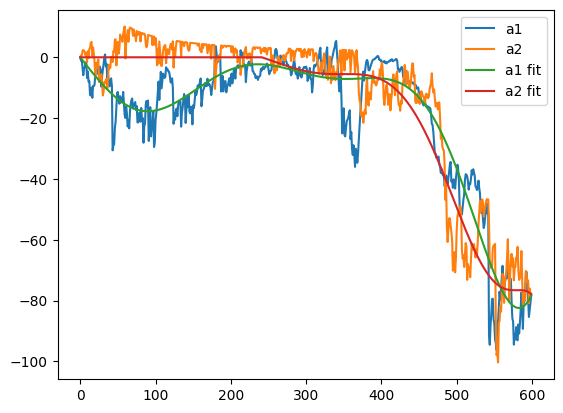

In [163]:
deg = 10
# a1_params = poly_fit(t_data, a_data[:,1], dim = deg, fit_intercept = False , ridge_alpha=0 * deg)
# #a1t = poly_corr(t_data, a1_params, alpha, intercept = False)
# a1t = poly(t_data, a1_params, intercept = False)

# a2_params = poly_fit(t_data, a_data[:,2], dim = deg, fit_intercept = False, ridge_alpha=0 * deg)
# a2t = poly_corr(t_data, a2_params, alpha, intercept = False)

a_data_a1 = a_data[:,1].copy()
a_data_a2 = a_data[:,2].copy()
# a1_params = poly_fit(t_data, a_data_a1, dim = deg, fit_intercept = False, ridge_alpha = 0.0)
# a2_params = poly_fit(t_data, a_data_a2, dim = deg, fit_intercept = False, ridge_alpha = 0.0)
# a1t = poly(t_data, a1_params, intercept = False)
# a2t = poly_corr(t_data, a2_params, alpha, intercept = False)
a1_params = bounded_polynom_fit(t_data, a_data_a1, deg = deg, ridge_alpha = 0.0)
a2_params = bounded_polynom_fit(t_data, a_data_a2, deg = deg, ridge_alpha = 0.0)

a1t = bounded_polynom(t_data, a_data_a1, a1_params)
a2t = bounded_polynom(t_data, a_data_a2, a2_params)
a2t = correction(t_data, a2t, alpha)

plt.plot(a_data[:,1], label = 'a1')
plt.plot(a_data[:,2], label = 'a2')

plt.plot(a1t, label = 'a1 fit')
plt.plot(a2t, label = 'a2 fit')
#plt.plot(moving_average(a_data[:,1],60), label = 'a1 ma fit')
plt.legend()

In [1411]:
@jit(nopython=True, cache = True)
def bounded_polynom_fit(x, y, deg, ridge_alpha = 0.0):
    x0 = x[0]
    x1 = x[-1]
    y0 = y[0]
    y1 = y[-1]
    c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
    c1 = (y1 - y0) / (x1 - x0)
    d1 = -x0 - x1
    d0 = x0 * x1

    A = np.zeros((len(x), deg - 2))
    x_i = np.ones(len(x))
    for i in range(0, deg - 2):
        A[:,i] = x_i * x * x + d1 * x_i * x + d0 * x
        x_i = x_i  * x
    A[:,0] += np.ones(len(x)) * c0
    A[:,1] += x * c1
    res = linear_least_squares(A, y, ridge_alpha)
    return res

@jit(nopython=True, cache = True)
def bounded_polynom(x, y, coef):
    deg = len(coef)
    x0 = x[0]
    x1 = x[-1]
    y0 = y[0]
    y1 = y[-1]
    c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
    c1 = (y1 - y0) / (x1 - x0)
    d1 = -x0 - x1
    d0 = x0 * x1
    
    res = np.zeros(len(x))
    x_i = np.ones(len(x))
    for i in range(0, deg):
        res += coef[i] * x_i
        x_i = x_i * x
    return (x * x + d1 * x + d0) * res + c1 * x + c0

In [25]:
x = t_data
y = a_data_a1
x0 = x[0]
x1 = x[-1]
y0 = y[0]
y1 = y[-1]
c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
c1 = (y1 - y0) / (x1 - x0)
d1 = -x0 - x1
d0 = x0 * x1
c0, c1, d0, d1

(0.0, -134.2217388633377, 0.0, -1.0)

In [1196]:
@jit(nopython=True, cache = True)
def poly(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, dim):
        res += coef[i] * data**(1 - fi + i)
    return res

(600, 2)

In [1623]:
@jit(nopython=True, cache = True)
def m_sampler_ou_old(alpha, a1t, a2t, dwt, init_state = None):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D = nu**2 / 2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for i in range(1, T):
        a1, a2 = a1t[i], a2t[i]
        a1dt, a2dt =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
        t = i/T
        xs = (xt[0] - mu) * np.exp(-theta * t)
        xsdt = -theta * xs
        sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
        sigma2dt = nu**2 - 2 * theta * sigma2
        p = (1 - 2 * a2 * sigma2)
        sigma2w = sigma2 / p
        sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
        xsw = (xs + a1 * sigma2) / p
        xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
        B = nu
        A = xswdt - (xt[i - 1] - mu - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
        xt[i] = xt[i - 1] + A * dt + B * dwt[i]
    return xt

@jit(nopython=True, cache = True)
def log_norm_ou_old(alpha: np.array, a1: np.array, a2: np.array, t: np.array, x0: np.array):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    xs = (x0 - mu) * np.exp(alpha2 * t)
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t))
    res = (2*xs*(a1 + a2*xs) + a1**2*sigma2) / (2 - 4*a2*sigma2) - 0.5 * np.log(1 - 2*a2*sigma2)
    return res

In [172]:
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

log_likelihood = np.zeros(latent_process_tr)
norm_log_data = np.zeros((T, latent_process_tr))

alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
mu = -alpha1 / alpha2


#a1t = np.zeros(T)
a1t = 14 * np.sin(8 * np.pi/2 * t_data)
a2t = -12 * np.cos(4 * np.pi/2 * t_data)**2
#a1t = np.ones(T) * 4
#a2t = np.ones(T) * (-1) * 0.01
#a1t = a1t * 0
#a2t = a2t * 0
lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt)
dt = 1/T
#lambda_data = p_sampler_ou(alpha, dwt)
for i in range(1, T):
    a1, a2 = a1t[i], a2t[i]
    norm_log_data[i] = log_norm_ou(alpha, a1, a2, 1/T, lambda_data[i - 1])
    #norm_log_data[i] = log_norm_ou(alpha, a1, a2, i/T, -alpha[0]/alpha[1])
for k in range(0, latent_process_tr):
    #copula_log_data = np.log(pdf(data.T, transform(lambda_data[:,k]) ))
    copula_log_data = np.log(np.maximum(copula.np_pdf()(pobs_data.T, copula.transform(lambda_data[:,k])), 1e-100))

    g = (a1t * (lambda_data[:,k] - 0.0 * mu) + a2t * (lambda_data[:,k] - 0.0 * mu)**2)
    log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)

-411.14826747120804


In [39]:
alpha = np.array([-0.19788412, -0.67066287, -0.70314979])
#alpha = np.array([0.5421, 0.9751, 0.1024])

In [177]:
log_likelihood = np.zeros(latent_process_tr)
norm_log_data = np.zeros((T, latent_process_tr))

alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
mu = -alpha1 / alpha2

disc = 50
T1 = disc * T
dwt = np.random.normal(0, 1, size = (T1, latent_process_tr)) * np.sqrt(1/T1)
t_data1 = np.linspace(0, 1, T1)

a1t = 14 * np.sin(8.116 * np.pi/2 * t_data1)
a2t = -12 * np.cos(0.454 * np.pi/2 * t_data1)**2

lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt)
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

idx = np.arange(0, T1, disc)
lambda_data = lambda_data[idx]
a1t = a1t[idx]
a2t = a2t[idx]

dt = 1/T
for i in range(1, T):
    a1, a2 = a1t[i], a2t[i]
    norm_log_data[i] = log_norm_ou(alpha, a1, a2, 1/T, lambda_data[i - 1])
for k in range(0, latent_process_tr):
    copula_log_data = np.log(np.maximum(copula.np_pdf()(pobs_data.T, copula.transform(lambda_data[:,k])), 1e-100))

    g = (a1t * (lambda_data[:,k] - 0.0 * mu) + a2t * (lambda_data[:,k] - 0.0 * mu)**2)
    log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)

-365.8264986329224


In [68]:
a1t = 14 * np.sin(8.116 * np.pi/2 * t_data1)
a2t = -12 * np.cos(0.454 * np.pi/2 * t_data1)**2
a1_res = []
a2_res = []
dt = 1/len(t_data1)
for i in range(1, len(t_data1)):
    a1dt, a2dt =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
    a1_res.append(a1dt)
    a2_res.append(a2dt)


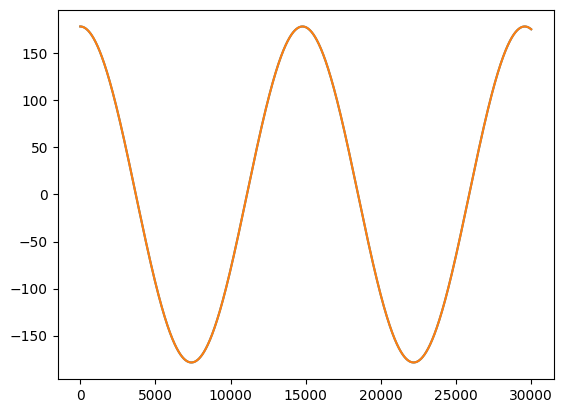

In [75]:
plt.plot(a1_res)
plt.plot(14 * 8.116 * np.pi/2 * np.cos(8.116 * np.pi/2 * t_data1))

In [150]:
# a1t = np.sin(8 * np.pi/2 * t_data)
# a2t = np.zeros(T)
p = p_sampler_ou(alpha, dwt)
m = m_sampler_ou(alpha, a1t, a2t, dwt)

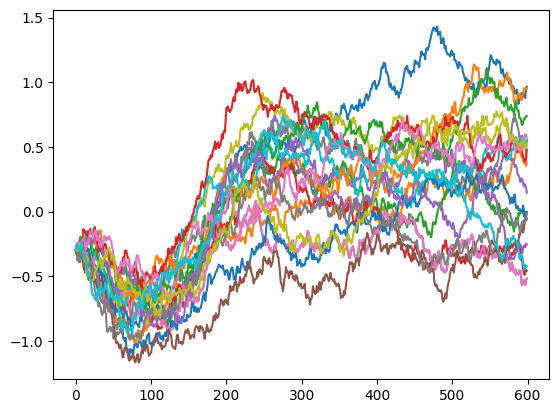

In [157]:
for i in range(0, 20):
    t = np.random.randint(0, latent_process_tr)
    plt.plot(m[:,t], label = 'm')

413


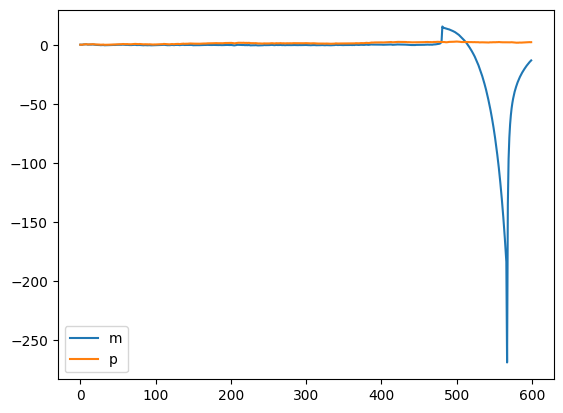

In [854]:
t = np.random.randint(0, latent_process_tr)
#t = 0
print(t)
plt.plot(m[:,t], label = 'm')

plt.plot(p[:,t], label = 'p')
plt.legend()

In [183]:
@jit(nopython=True, cache = True)
def poly_corr(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 1
    exp_res = np.exp(-0.05*(max_res - res))
    return 1 / (1 + exp_res) * res

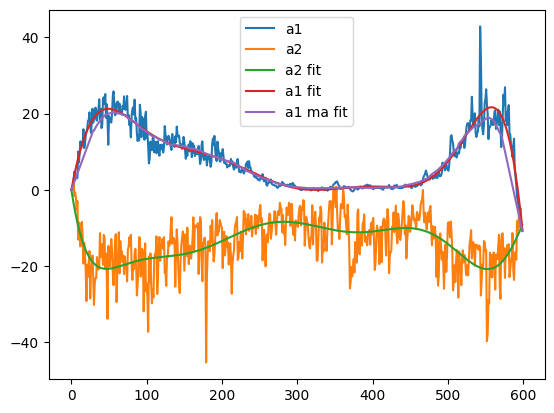

In [739]:
a1_params = poly_fit(t_data, a_data[:,1], dim = 10, fit_intercept = False)
#a1t = poly_corr(t_data, a1_params, alpha, intercept = False)
a1t = poly(t_data, a1_params, intercept = False)

a2_params = poly_fit(t_data, a_data[:,2], dim = 10, fit_intercept = False)
a2t = poly_corr(t_data, a2_params, alpha, intercept = False)

plt.plot(a_data[:,1], label = 'a1')
plt.plot(a_data[:,2], label = 'a2')

plt.plot(a2t, label = 'a2 fit')
plt.plot(a1t, label = 'a1 fit')
plt.plot(moving_average(a_data[:,1],60), label = 'a1 ma fit')
plt.legend()

In [834]:
p = p_sampler_ou(alpha, dwt)
#a1_data = moving_average(a_data[:,1], 50)
a1_params = poly_fit(t_data, a_data[:,1], dim = 10, fit_intercept = False)
a1t = poly(t_data, a1_params, intercept = False)

a2_params = poly_fit(t_data, a_data[:,2], dim = 10, fit_intercept = False)
a2_data = poly_corr(t_data, a2_params, alpha, intercept = False)
#a2_data = np.zeros(T)
m = m_sampler_ou(alpha, a1t, a2t, dwt)

300


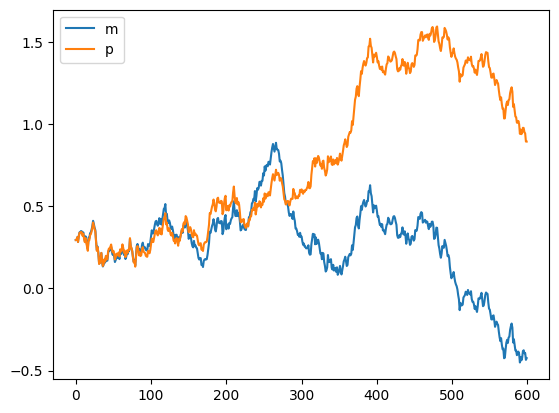

In [435]:
t = np.random.randint(0, latent_process_tr)
#t = 0
print(t)
plt.plot(m[:,t], label = 'm')
plt.plot(p[:,t], label = 'p')
plt.legend()

In [71]:
def mod_abs(x):
    b = 100
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

def poly_corr(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 2
    # exp_res = np.exp(-1*(max_res - res))
    # return 1 / (1 + exp_res) * res
    return -(mod_abs(max_res - res) - max_res - res) / 2 - 2


In [855]:
# a2_params = np.array([ 4.38482739e+02, -2.31159093e+03,  1.88422857e+03,  3.46489738e+04,
#        -1.82846010e+05,  4.50592534e+05, -6.54475441e+05,  5.77984013e+05,
#        -2.87520608e+05,  6.15764018e+04])
a2_nocorr = poly(t_data, a2_params, intercept = False)
a2_corr = poly_corr(t_data, a2_params, alpha, intercept = False)

In [856]:
alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
max_a2 = 1 / (2 * sigma2)
max_a2 = np.clip(max_a2, -100000, 50)

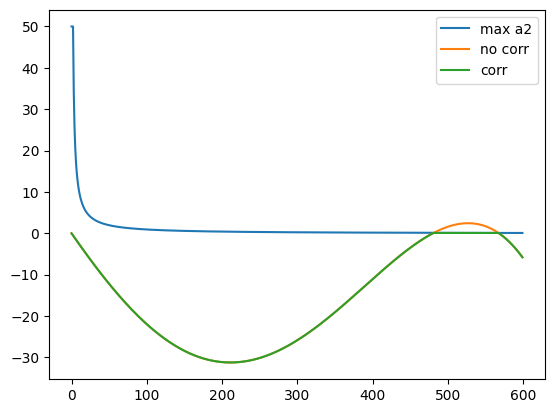

In [857]:
plt.plot(max_a2, label = 'max a2')

plt.plot(a2_nocorr, label = 'no corr')
#plt.plot(-(np.abs(a2_nocorr - max_a2) - a2_nocorr - max_a2) / 2 - 1, label = 'exp')
plt.plot(a2_corr, label = 'corr')
plt.legend()